# 4.2 Implementation of Automatic Differentiation. 

In this notebook, I illustrate what is Automatic differentiation and how it can be implemented.  There are mainly two types of automatic differentiation.  Forward mode and reverse mode.  In this notebook, I will only be showing you forward mode automatic differentiation, which is the algorithm behind the `ForwardDiff()` package.  The `Zygote()` package uses reverse mode algrithm.  This example is adapted from 

https://www.youtube.com/watch?v=B-1hsAfdGHw

---

## Univariate functions 

The main idea behind automatic differentiation is to break a complex function down into elementary operations and then we use simple rules to calculate the derivatives.   Let's illustrate this with an example. Suppose we want to take derivative of the function

$f(x)=3x+\sin(x^2)$

We break the function $f(x)$ down into small elementary computations

$v_1=x$

$v_2=v_1^2$

$v_3=3v_1$

$v_4=\sin(v_2)$

$v_5=v_3+v_4$


where $v_5=f$.  We want to take derivative with respect to $v_1=x$.  Below the dot on top of the $v_i$ represent derivative with repesct to $x$.

$\dot{v}_1=1$

$\dot{v}_2=2v_1\dot{v}_1$

$\dot{v}_3=3\dot{v}_1$

$\dot{v}_4=\cos(v_2)\dot{v}_2$

$\dot{v}_5=\dot{v}_3+\dot{v}_4$

We can summarise the expression for $v_i$ and $\dot{v}_i$ in the table below

| $i$ | $v_i$ | $\dot{v}_i$| $(v_i, \dot{v}_i)$ |
|:----:|:------:|:---------:|:---------:|
| $1$   | $v_1=x$| $\dot{v}_1=1$| $(x,1)$|
| $2$   | $v_2=v_1^2$| $\dot{v}_2=2v_1\dot{v}_1$| $(v_1^2,2v_1\dot{v}_1)$|
| $3$   | $v_3=3v_1$| $\dot{v}_3=3\dot{v}_1$| $(3v_1,3\dot{v}_1)$|
| $4$   | $v_4=\sin(v_2)$| $\dot{v}_4=\cos(v_2)\dot{v}_2$|$(\sin(v_2),\cos(v_2)\dot{v}_2)$|
| $5$   | $v_5=v_3+v_4$| $\dot{v}_5=\dot{v}_3+\dot{v}_4$|$(v_3+v_4,\dot{v}_3+\dot{v}_4)$|

Note the following, 

* once we know all the values in the first row, we can calculate the numerical values of $v_i$ and $\dot{v}_i$  in the 2nd row, then the 3rd row etc.  
* For every fundamental operation, i.e. everytime you perform a $+$,$^2$,$\sin()$, you will need to remember the value of $v_i$ AND the value of its derivative, $\dot{v}_i$ 

At this stage, it will be useful to define the idea of a Dual number.  In this notebook, a Dual number is a number that consist of two elements.  The value of the function and its derivative.  We will represent the  dual number  by () with a comma separating the function and its derivative, i.e. $(v_i,\dot{v}_i)$. This Dual number is shown in the third column in the table above.


Let's put in some numbers to calculate the numerical  value of $df/dx(x=\pi/2)$. We can go from top to bottom


| $i$ | $v_i$ | $\dot{v}_i$|  $(v_i, \dot{v}_i)$ |
|:----:|:------:|:---------:|:---------:|
| $1$   | $v_1=x=\pi/2$| $\dot{v}_1=1$| $(\pi/2,1)$|
| $2$   | $v_2=v_1^2=(\pi/2)^2$| $\dot{v}_2=2v_1\dot{v}_1=2(\pi/2)(1)$|$(\pi^2/4,\pi)$|
| $3$   | $v_3=3\times \pi/2$| $\dot{v}_3=3\times 1$| $(3\pi/2,3)$|
| $4$   | $v_4=\sin(v_2)=\sin(\pi^2/4)$| $\dot{v}_4=\cos(\pi^2/4)\pi$| $(\sin(\pi^2/4),\pi\cos(\pi^2/4))$|
| $5$   | $v_5=v_3+v_4$| $\dot{v}_5=\dot{v}_3+\dot{v}_4$|$(3 \pi/2+\sin(\pi^2/4),3+\pi\cos(\pi^2/4))$|


Therefore 
$\dot{v}_3=3+\cos((\pi/2)^2)\pi=3-2.4542495411512917=0.5457504588487083$.  If you differentiate $f(x)=3x+\sin(x^2)$ directly, you will get $3+2x\cos((x^2)$, which when you evaluate at $x=\pi/2$, you will get the same value.  


<u>Exercise Ex01:</u>  Go through the exercise above and calculate the value of $df/dx(x=\pi)$.

Herein shows the main difference between symbolic and automatic differentiation.  For symbolic differentiation, you will get an expression for the derivative.  In the example above, the symbolic derivative is the expression $3+2x\cos(x^2)$.  If you want to calculate the derivative using symbolic differentiation, all you will need to just substitute the numerical value of $x$ and evaluate the expression. For automatic differentiation,  everytime you want to calculate the value of the derivative (for a different value of $x$), you will need to run through the numbers in the table above from top to bottom, i.e. calculate the numerical values $v_i$'s and $\dot{v}_i$'s.

For this simple problem above, you can easily perform symbolic differentiation.  However, when you have a complex function, such as a Neural Network (see later in the course), it would not be possible to find the symbolic expression for the derivative.  For these complex functions, you should use automatic differentiation. 

---

In [18]:
using CairoMakie

We will now show how you can use a Dual number to automatically differentate a function.  First define a Dual number and store it in a `struct`.  This Dual struct has two fields, $v$ which is the value of the function, and $\partial$ which is the value of its derivative. 

In [19]:
struct Dual <: Number
    v::Float64 #value of the function
    ∂::Float64 #its derivative
end

We now implement methods/operations/functions for this `Dual` struct.  These methods will accept `Dual` struct and produce new  `Dual` struct by applying the chain rule for the $\partial$ field

In [ ]:
import Base:+,-,*,sin,^
+(a::Dual,b::Dual)=Dual(a.v+b.v,a.∂+b.∂) 
+(a::Dual,b::Number)=Dual(a.v+b,a.∂) 
-(a::Dual,b::Dual)=Dual(a.v-b.v,a.∂-b.∂) 
*(a::Dual,b::Dual)=Dual(a.v*b.v,a.v*b.∂+b.v*a.∂) 
*(a::Number,b::Dual)=Dual(a*b.v,a*b.∂) 
^(a::Dual,n::Integer)=Dual(a.v^n,n*a.v^(n-1)*a.∂) 
sin(a::Dual)=Dual(sin(a.v),cos(a.v)*a.∂) 

sin (generic function with 26 methods)

We can now experiment with `Dual` number.  Define a `Dual` number `x` such that its value is 8 and have the value 1.0 for $\partial$.  This value of 1.0 can be thought of as the "seed" for its derivative.  We can think of the value of $x$ is 8 and $\partial x/\partial x=1$.

In [21]:
x=Dual(8.0,1.0)

Dual(8.0, 1.0)

For $x^2$, its derivative is $2x$.  So the value field should be $8\times8=64$ and the value of the derivative, $\partial $ is $2\times8=16$.  

In [22]:
x^2

Dual(64.0, 16.0)

Note that we get BOTH the value of the function AND its derivative by just evaluating the function (for a given value of $x$).

Let's try a more complicated example

* Define a function $f(x)=3x+\sin(x^2)$.  
* The symbolic derivitative is $f'(x)=3+2x\cos(x^2)$.  
* If $x=\pi/2$ then 
    $f(\pi/2)=3*(\pi/2)+\sin(\pi^2/4)=5.336654933024389s$.
    $f'(\pi/2)=3+\pi\cos(\pi^2/4)=0.5457504588487083$.

Let's see if we can get this with our Dual number approach

In [15]:
x=Dual(π/2.0,1.0)  #the value of x=pi/2 and dx/dx=1.0
f(x::Dual)=3*x+sin(x^2) #define the function f(x)=3x+sin(x^2)

f (generic function with 1 method)

In [16]:
f(x)

Dual(5.336654933024389, 0.5457504588487083)

If we now define another function $g(x)=\sin(x^2)+x^3$

In [8]:
g(x::Dual)=sin(x^2)+x^3

g (generic function with 1 method)

In [9]:
g(x)

Dual(4.500050537677176, 4.947953759665727)

Check if this is correct.  $dg/dx=2x\cos(x^2)+3x^2$

In [10]:
π*cos(π^2/4)+3*(π/2)^2

4.947953759665727

---

Now let's do another example   
$f(x)=\sin(x^2+3)+x^3$

For this function

$\frac{df}{dx}(x)=2x\cos(x^2+3)+3x^2$

We will calculate the derivative of $f(x)$ using dual numbers and then plot it and compare with the analytical solution 

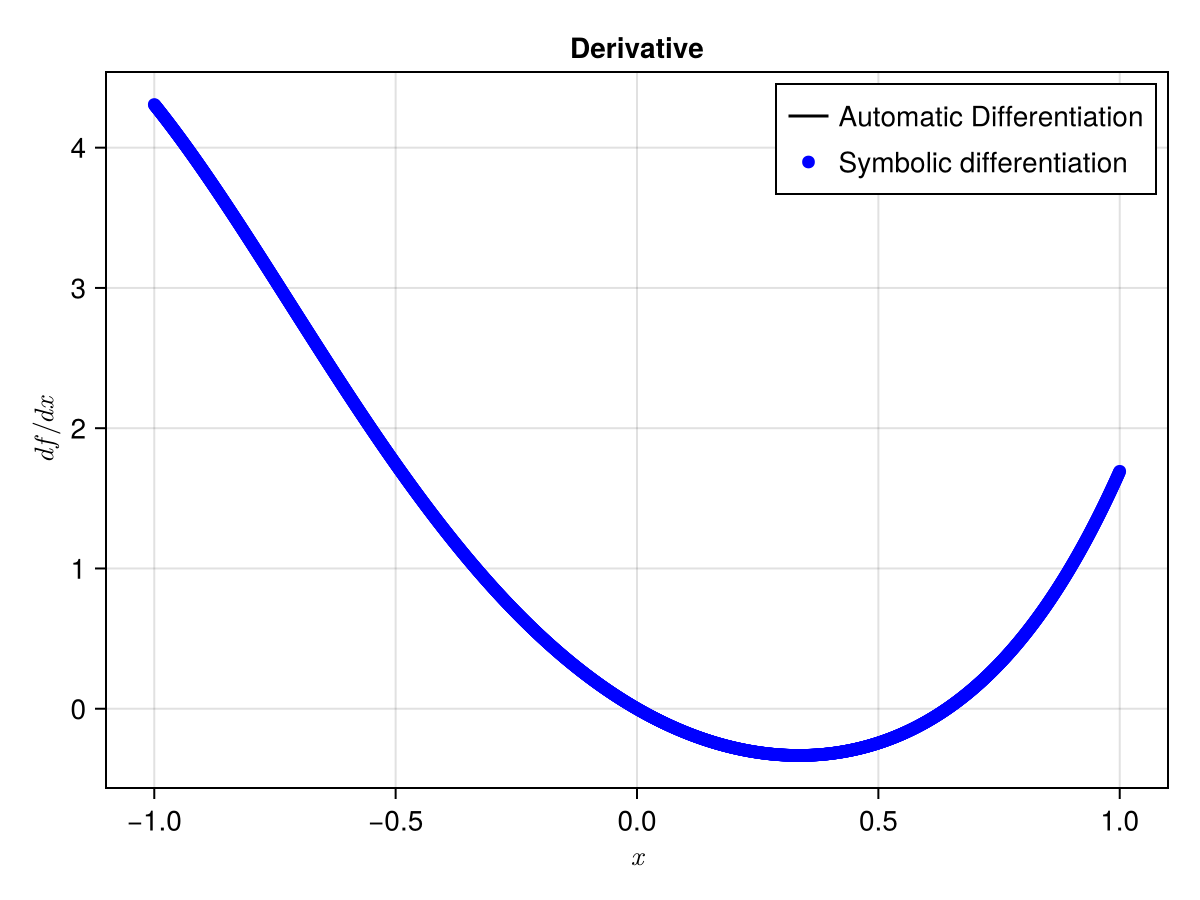

In [17]:
xplot=-1:0.001:1.0
f(x::Dual)=sin(x^2+3.0)+x^3
dfdx(x)=2x*cos(x^2+3)+3x^2
dfAuto=[f(Dual(x,1.0)).∂ for x in xplot]; #Automatic differentiation for all values of x in xplot
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"df/dx",title = "Derivative")
lines!(ax,xplot,dfAuto,color=:black,label="Automatic Differentiation")
scatter!(ax,xplot,dfdx.(xplot),color=:blue,label="Symbolic differentiation")
axislegend(ax,position=:rt)
fig

The two lines fall on top of each other.

---
## Multivariable function example

The Dual number approach also works with functions of more than 1 variable.  Suppose we want to differentiate a function of two variables

$f(x_1,x_2)=x_1 x_2 +\sin(x_1)$

Again, we would break it down into elementary operations

$v_1=x_1$

$v_2=x_2$

$v_3=v_1 v_2$

$v_4=\sin(v_1)$

$v_5=v_3+v_4$




| $i$ | $v_i$ | $\dot{v}_i$|
|:----:|:------:|:---------:|
| $1$   | $v_1=x_1$| $\dot{v}_1$|
| $2$   | $v_2=x_2$| $\dot{v}_2$|
| $3$   | $v_3=v_1v_2$| $\dot{v}_3=\dot{v}_1v_2+v_1\dot{v}_2$|
| $4$   | $v_4=\sin{v_1}$| $\dot{v}_4=\dot{v}_1\cos{v_1}$|
| $5$   | $v_5=v_3+v_4$| $\dot{v}_5=\dot{v}_3+\dot{v}_4$|

The $ ^{.}$ operator indicates derivatives either with respect to $x_1$ or $x_2$.  If we want to take derivative with respect to $x_1$, then the $ ^{.}$ represent derivative with respect to $x_1$.  Similar comment for $x_2$.  Hence, If we want to calculate derivative $\frac{\partial f}{\partial x_1} (x_1=\pi/2,x_2=\pi/2)$  we set $\dot{v}_1=1$ and $\dot{v}_2=0$ (since $\frac{\partial x_1}{\partial x_1}=1$ and $\frac{\partial x_2}{\partial x_1}=0$) in the table above and start the calculation from top to bottom



| $i$ | $v_i$ | $\dot{v}_i$|
|:----:|:------:|:---------:|
| $1$   | $v_1=\pi/2$| $\dot{v}_1=1$|
| $2$   | $v_2=x_2=\pi/2$| $\dot{v}_2=0$|
| $3$   | $v_3=(\pi/2)( \pi/2)$| $\dot{v}_3=(1) (\pi/2)+(\pi/2) (0)=\pi/2$|
| $4$   | $v_4=\sin(\pi/2)=1$| $\dot{v}_4=(1)\cos(\pi/2)=0$|
| $5$   | $v_5=(\pi/2)^2+1$| $\dot{v}_5=\pi/2$|

<u>Exercise Ex02:</u>  Try calculating $\frac{\partial f}{\partial x_2} (x_1=\pi/2,x_2=\pi/2)$.  What values should we use for  $\dot{v}_1$ and $\dot{v}_2$?


----

Now we try to find the partial derivatives that make up the 2d function

$f(x_1,x_2)=\frac{3}{2}x_1^2+2x_1x_2+3x_2^2-2x_1+8x_2$

In [23]:
quad(x,y)=(3.0/2.0)*x^2+2*x*y+3*y^2-2*x+8*y

quad (generic function with 1 method)

To find

$\frac{\partial f}{\partial x}$ at $(x,y)=(1.0,1.0)$

In [24]:
xp=Dual(1.0,1.0)
yp=Dual(1.0,0.0)
quad(xp,yp)

Dual(12.5, 3.0)

To find

$\frac{\partial f}{\partial y}$ at $(x,y)=(1.0,1.0)$

In [25]:
xp=Dual(1.0,0.0)
yp=Dual(1.0,1.0)
quad(xp,yp)

Dual(12.5, 16.0)

<u>Exercise Ex03:</u>  What do you need to type in to find

$\frac{\partial f}{\partial y}$ at $(x,y)=(3.0,1.0)$


* Observe that you need to go through all the calculations every time you need to calculate a derivative. 

*  So for a multivariate (let's say two dimensional) problem, of you want to calculate the gradient, $\frac{\partial f}{\partial x}$ and $\frac{\partial f}{\partial y}$,  you need to go through all the calculations in the table twice.  Once to get $\frac{\partial f}{\partial x}$ and the other time to get 
$\frac{\partial f}{\partial y}$.  

* If you want to get the value of the gradient at $(x,y)=(1,1)$, to obtain the value of $\frac{\partial f}{\partial x}$,  you need to run through the calculation with 

```
    xp=Dual(1.0,1.0) 
    yp=Dual(1.0,0.0)
    quad(xp,yp)
```

and then to get $\frac{\partial f}{\partial x}$ you need to execute

```
    xp=Dual(1.0,0.0) 
    yp=Dual(1.0,1.0)
    quad(xp,yp)
```



* For real problems, you have many more than two variables, sometimes in the millions!  So if you use this method, you will need to do the calculations a million times, just to get the gradient!

* The method I have covered above is called the "forward mode" automatic differentiation.  There is another (arguably more important) mode called the "reverse mode" automatic diffefentiation.  In "reverse mode" automatic diffefentiation, you only need to go through the calculations in the table above twice to get all the gradients with respect to all the inputs....even though you might have lots of inputs.  "reverse mode" automatic differentiation is quite complex and I won't be going through it in this course. If you are interested, I encourage you to look it up in your own time.